x_train: (50000, 32, 32, 3) uint8
y_train: (50000, 1) uint8
x_test : (10000, 32, 32, 3) uint8
y_test : (10000, 1) uint8


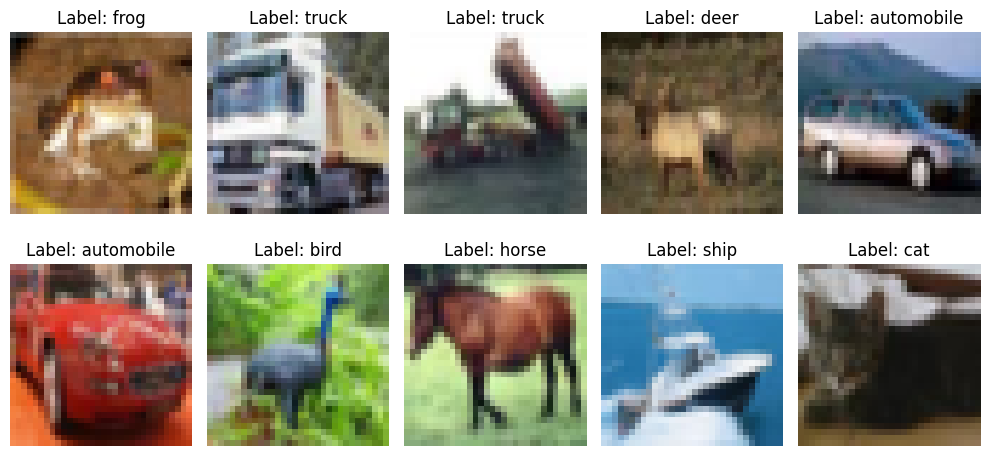

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

np.random.seed(42)
keras.backend.clear_session()

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

X_train = x_train.astype("float32") / 255.0
X_test  = x_test.astype("float32") / 255.0

y_train_ = y_train.squeeze()
y_test_  = y_test.squeeze()


print("x_train:", x_train.shape, x_train.dtype)  # (50000, 32, 32, 3)
print("y_train:", y_train.shape, y_train.dtype)  # (50000, 1)
print("x_test :", x_test.shape,  x_test.dtype)   # (10000, 32, 32, 3)
print("y_test :", y_test.shape,  y_test.dtype)   # (10000, 1)

class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]


fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_train[i])
    ax.set_title(f'Label: {class_names[y_train[i][0]]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [31]:
model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Flatten(),
    *[keras.layers.Dense(100, activation='elu',kernel_initializer="he_normal") for i in range(20)],
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       307,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,210 (1.91 MB)

 Trainable params: 500,210 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Using Nadam optimization and early stopping, train the network and remember to search for the right learning rate

import tensorflow as tf

lastbestvalacc = 0
bestlr = 0

lr_list = [1e-5, 1e-4,  1e-3, 1e-2, 1e-1]
results = []

for lr in lr_list:
    keras.backend.clear_session()
    tf.random.set_seed(42)
    np.random.seed(42)

    model = keras.Sequential([
        keras.layers.Input(shape=(32, 32, 3)),
        keras.layers.Flatten(),
        *[keras.layers.Dense(100, activation='elu',kernel_initializer="he_normal") for i in range(20)],
        keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Nadam(learning_rate=(lr)),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train_,
        validation_split=0.1,
        epochs=20,
        batch_size=64,
        callbacks=[early_stop],
    )

    best_val_loss = min(history.history["val_loss"])
    best_val_acc  = max(history.history["val_accuracy"])
    results.append((lr, best_val_loss, best_val_acc))

    print(f"lr={lr:.0e}  best_val_loss={best_val_loss:.4f}  best_val_acc={best_val_acc:.4f}")
    if best_val_acc > lastbestvalacc:
        bestlr = lr
        lastbestvalacc = best_val_acc

print(f'bestlr: {bestlr}')


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.2096 - loss: 2.2237 - val_accuracy: 0.2638 - val_loss: 2.0120
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.2969 - loss: 1.9348 - val_accuracy: 0.3134 - val_loss: 1.8974
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3371 - loss: 1.8346 - val_accuracy: 0.3440 - val_loss: 1.8267
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3640 - loss: 1.7689 - val_accuracy: 0.3618 - val_loss: 1.7783
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3818 - loss: 1.7222 - val_accuracy: 0.3742 - val_loss: 1.7440
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3944 - loss: 1.6861 - val_accuracy: 0.3820 - val_loss: 1.7178
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4041 - loss: 1.6568 - val_accuracy: 0.3856 - val_loss: 1.6956
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4138 - loss: 1.6322 - val_accuracy

In [33]:
# a real go with the winning lr

import os, datetime

best_lr = bestlr
keras.backend.clear_session()

base_dir = r"C:\Users\nisse\Skola\DIL700\Assignment3.3"

log_dir = os.path.join(
    base_dir, "logs", "cifar10", "nadam_baseline",
    f"lr_{best_lr}",
    datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)
tb = keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=0)

keras.backend.clear_session()
model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Flatten(),
    *[keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal") for i in range(20)],
    keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=float(best_lr)),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train_,
    validation_split=0.1,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, tb],
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test, y_test_, verbose=0)
print("Test accuracy:", test_acc)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.3088 - loss: 1.9111 - val_accuracy: 0.3212 - val_loss: 1.8729
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3879 - loss: 1.6899 - val_accuracy: 0.3652 - val_loss: 1.8022
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4233 - loss: 1.6003 - val_accuracy: 0.3950 - val_loss: 1.7293
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4460 - loss: 1.5403 - val_accuracy: 0.4226 - val_loss: 1.6353
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4646 - loss: 1.4959 - val_accuracy: 0.4402 - val_loss: 1.5761
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4762 - loss: 1.4605 - val_accuracy: 0.4470 - val_loss: 1.5376
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4879 - loss: 1.4303 - val_accuracy: 0.4522 - val_loss: 1.5168
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4990 - loss: 1.4032 - val_accuracy: 

In [34]:
# learning rate exploration with batch normalization

import tensorflow as tf

lastbestvalacc = 0
bestlr = 0

lr_list = [1e-5, 1e-4,  1e-3, 1e-2, 1e-1]
results = []

for lr in lr_list:
    keras.backend.clear_session()
    tf.random.set_seed(42)
    np.random.seed(42)

    model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Flatten(),

    *[
        layer
        for _ in range(20)
        for layer in (
            keras.layers.Dense(
                100,
                kernel_initializer="he_normal",
                use_bias=False
            ),
            keras.layers.BatchNormalization(),
            keras.layers.Activation("elu"),
        )
    ],

    keras.layers.Dense(10, activation="softmax")
])

    model.compile(
        optimizer=keras.optimizers.Nadam(learning_rate=(lr)),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train_,
        validation_split=0.1,
        epochs=20,
        batch_size=64,
        callbacks=[early_stop],
    )

    best_val_loss = min(history.history["val_loss"])
    best_val_acc  = max(history.history["val_accuracy"])
    results.append((lr, best_val_loss, best_val_acc))

    print(f"lr={lr:.0e}  best_val_loss={best_val_loss:.4f}  best_val_acc={best_val_acc:.4f}")
    if best_val_acc > lastbestvalacc:
        bestlr = lr
        lastbestvalacc = best_val_acc

print(f'bestlr: {bestlr}')



Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.1686 - loss: 2.4625 - val_accuracy: 0.2246 - val_loss: 2.1966
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.2582 - loss: 2.0976 - val_accuracy: 0.2784 - val_loss: 2.0339
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3016 - loss: 1.9668 - val_accuracy: 0.3120 - val_loss: 1.9447
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3298 - loss: 1.8855 - val_accuracy: 0.3344 - val_loss: 1.8865
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3506 - loss: 1.8251 - val_accuracy: 0.3480 - val_loss: 1.8487
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3675 - loss: 1.7770 - val_accuracy: 0.3546 - val_loss: 1.8162
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3844 - loss: 1.7366 - val_accuracy: 0.3644 - val_loss: 1.7935
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3966 - loss: 1.7016 - val_ac

In [35]:
# a real go with the winning lr for batch normalization

import os, datetime

best_lr = bestlr
keras.backend.clear_session()

base_dir = r"C:\Users\nisse\Skola\DIL700\Assignment3.3"

log_dir = os.path.join(
    base_dir, "logs", "cifar10", "batch_norm",
    f"lr_{best_lr}",
    datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)
tb = keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=0)

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Flatten(),

    *[
        layer
        for i in range(20)
        for layer in (
            keras.layers.Dense(
                100,
                kernel_initializer="he_normal",
                use_bias=False
            ),
            keras.layers.BatchNormalization(),
            keras.layers.Activation("elu"),
        )
    ],
    keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=float(best_lr)),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train_,
    validation_split=0.1,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, tb],
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test, y_test_, verbose=0)
print("Test accuracy:", test_acc)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 26ms/step - accuracy: 0.3016 - loss: 1.9660 - val_accuracy: 0.3278 - val_loss: 1.8955
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 77ms/step - accuracy: 0.4033 - loss: 1.6710 - val_accuracy: 0.3806 - val_loss: 1.7393
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.4455 - loss: 1.5584 - val_accuracy: 0.3914 - val_loss: 1.7403
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.4777 - loss: 1.4779 - val_accuracy: 0.3970 - val_loss: 1.7411
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.5025 - loss: 1.4112 - val_accuracy: 0.4084 - val_loss: 1.7128
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5251 - loss: 1.3511 - val_accuracy: 0.3934 - val_loss: 1.7787
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5460 - loss: 1.2952 - val_accuracy: 0.3988 - val_loss: 1.8005
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5668 - loss: 1.2430 - 